In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

In [4]:
churn_data = pd.read_csv("Churn_Modelling.csv")
churn_data.head(3)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


In [5]:
churn_data=churn_data.drop(columns=['RowNumber','CustomerId','Surname'])
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [6]:
churn_data.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [8]:
for i in churn_data.columns:
    print(churn_data[i].value_counts())
    print('================================================')

CreditScore
850    233
678     63
655     54
705     53
667     53
      ... 
358      1
412      1
382      1
373      1
419      1
Name: count, Length: 460, dtype: int64
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
Gender
Male      5457
Female    4543
Name: count, dtype: int64
Age
37    478
38    477
35    474
36    456
34    447
     ... 
84      2
82      1
88      1
85      1
83      1
Name: count, Length: 70, dtype: int64
Tenure
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64
Balance
0.00         3617
130170.82       2
105473.74       2
113957.01       1
85311.70        1
             ... 
88381.21        1
155060.41       1
57369.61        1
75075.31        1
116363.37       1
Name: count, Length: 6382, dtype: int64
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64
HasCrCard
1    7055
0    2945
Name: count, dtype:

In [9]:
churn_data[churn_data.Balance==0.0]

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.0,1,1,1,101348.88,1
3,699,France,Female,39,1,0.0,2,0,0,93826.63,0
6,822,France,Male,50,7,0.0,2,1,1,10062.80,0
11,497,Spain,Male,24,3,0.0,2,1,0,76390.01,0
12,476,France,Female,34,10,0.0,2,1,0,26260.98,0
...,...,...,...,...,...,...,...,...,...,...,...
9989,841,Spain,Male,28,4,0.0,2,1,1,179436.60,0
9992,726,Spain,Male,36,2,0.0,1,1,0,195192.40,0
9994,800,France,Female,29,2,0.0,2,0,0,167773.55,0
9995,771,France,Male,39,5,0.0,2,1,0,96270.64,0


In [10]:
churn_data['Geography']= churn_data['Geography'].map({'France':0,'Germany':1,'Spain':2})
churn_data['Gender'] = churn_data['Gender'].map({'Female':0,'Male':1})

In [11]:
churn_data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [12]:
churn_data.Exited.value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

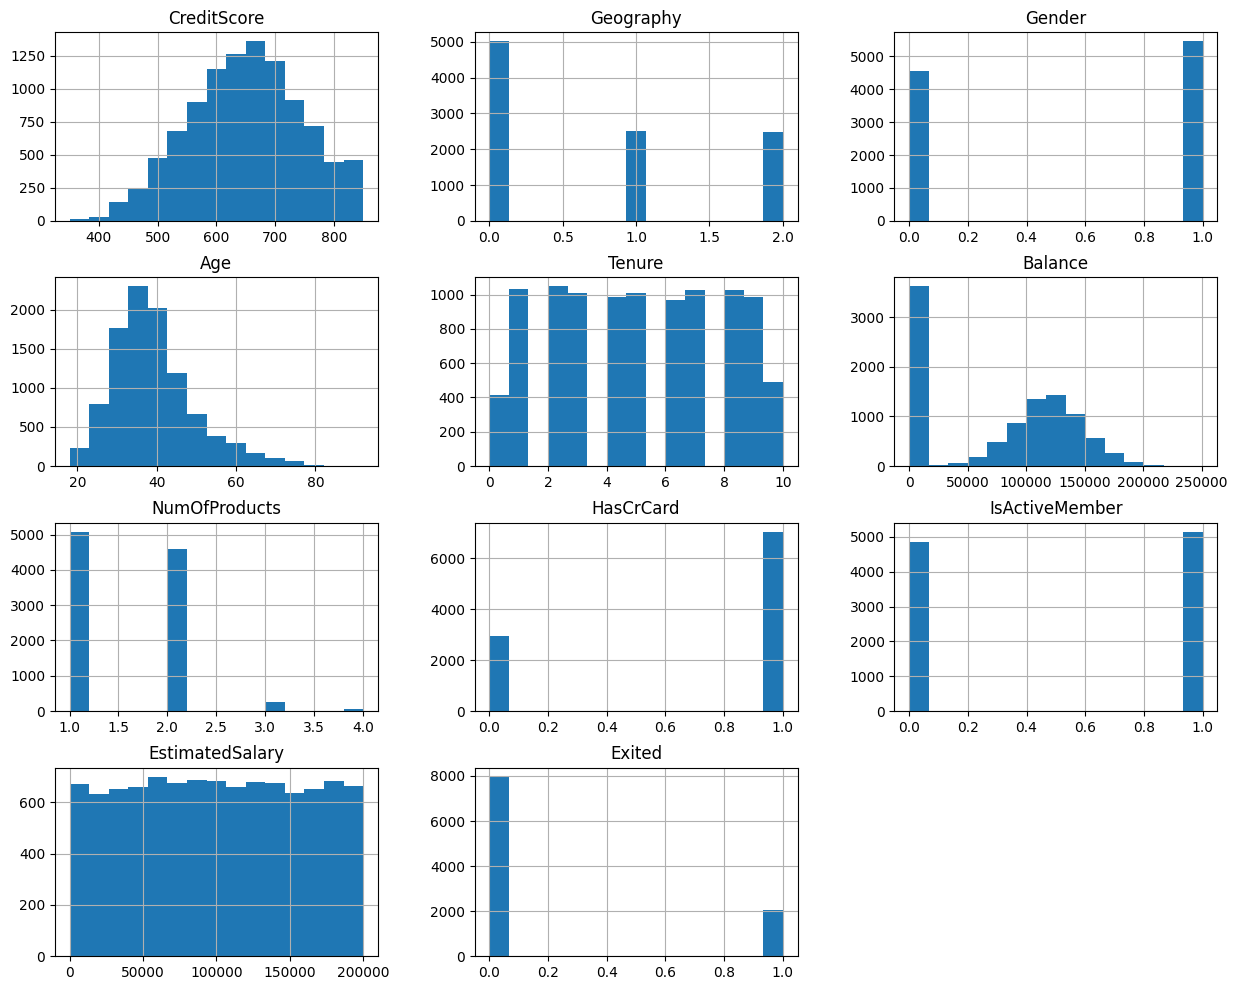

In [13]:
churn_data.hist(figsize=(15,12), bins=15)
plt.title("Features Distribution")
plt.show()

<Axes: >

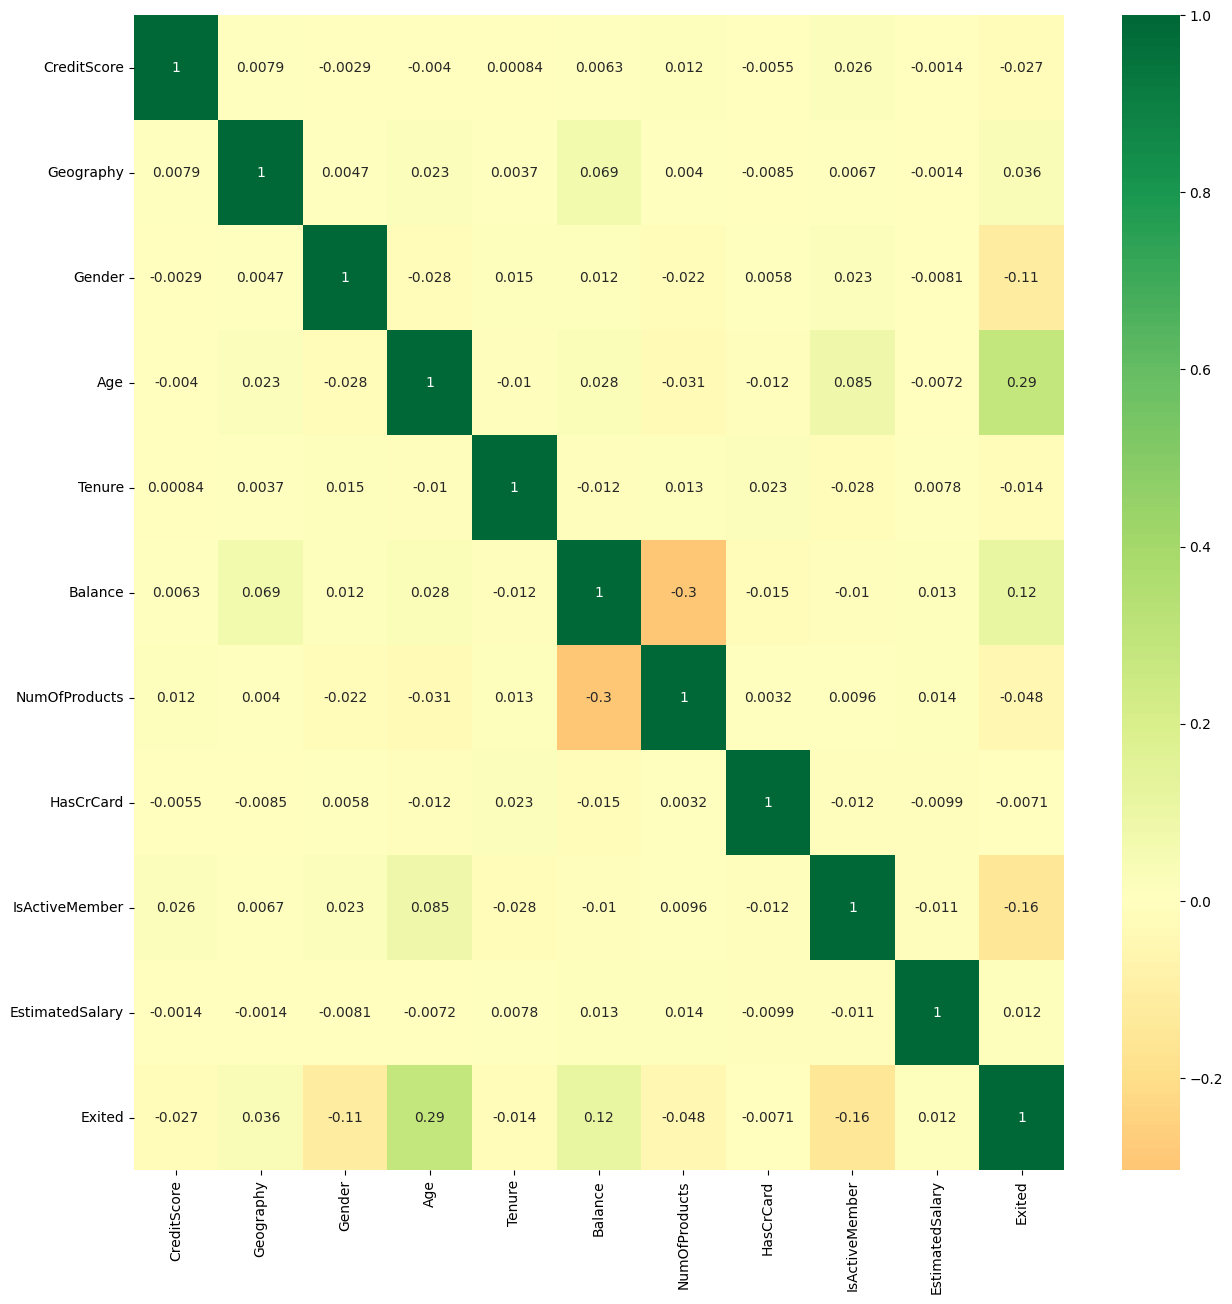

In [14]:
plt.figure(figsize=(15,15))
sns.heatmap(churn_data.corr(), annot=True, cmap="RdYlGn", center=0)

In [15]:
x = churn_data.drop(columns=['Exited'], axis=1)
y = churn_data.Exited

In [16]:
x_train, x_test, y_train,y_test = train_test_split(x,y, test_size=0.2, random_state = 42)

In [17]:
sc = StandardScaler()
x_train_std = sc.fit_transform(x_train)
x_test_std = sc.transform(x_test)

In [19]:
x_train_tensor = torch.tensor(x_train_std, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long).view(-1)
x_test_tensor = torch.tensor(x_test_std, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long).view(-1)

train_ds = TensorDataset(x_train_tensor, y_train_tensor)
test_ds = TensorDataset(x_test_tensor, y_test_tensor)

train_loader = DataLoader(train_ds, shuffle=True, batch_size=32)
test_loader = DataLoader(test_ds, shuffle=False, batch_size=2)

In [26]:
class PredictModel(nn.Module):
    def __init__(self, ip_dim):
        super(PredictModel, self).__init__()
        self.flat = nn.Flatten()
        self.seq = nn.Sequential(
            nn.Linear(ip_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16,2),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.seq(self.flat(x))

In [27]:
x_train.shape

(8000, 10)

In [28]:
model = PredictModel(10)

In [29]:
model

PredictModel(
  (flat): Flatten(start_dim=1, end_dim=-1)
  (seq): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=16, out_features=2, bias=True)
    (10): Sigmoid()
  )
)

In [30]:
criteria = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [32]:
epochs = 100

for ep in range(epochs):
    
    model.train()
    run_loss = 0.0

    for ip, target in train_loader:
        optimizer.zero_grad()
        op = model(ip)
        loss = criteria(op, target)
        loss.backward()
        optimizer.step()
        run_loss += loss.item()*ip.size(0)
    
    ep_loss = run_loss/len(train_loader.dataset)

    if(ep+1)%10 == 0:
        print(f"Epoch [{ep+1}/{epochs}], Loss: {ep_loss:.4f}")

Epoch [10/100], Loss: 0.4691
Epoch [20/100], Loss: 0.4496
Epoch [30/100], Loss: 0.4482
Epoch [40/100], Loss: 0.4447
Epoch [50/100], Loss: 0.4411
Epoch [60/100], Loss: 0.4409
Epoch [70/100], Loss: 0.4397
Epoch [80/100], Loss: 0.4370
Epoch [90/100], Loss: 0.4376
Epoch [100/100], Loss: 0.4368


In [33]:
model.eval()
with torch.no_grad():
    preds = model(x_train_tensor)

    # loss (correct)
    test_loss = criteria(preds, y_train_tensor.view(-1))
    print(f"\n✅ Train Loss: {test_loss.item():.4f}")

    # convert logits → predicted class
    predicted_classes = torch.argmax(preds, dim=1)

    # convert to numpy
    y_true = y_train_tensor.view(-1).cpu().numpy()
    y_pred = predicted_classes.cpu().numpy()


✅ Train Loss: 0.4276


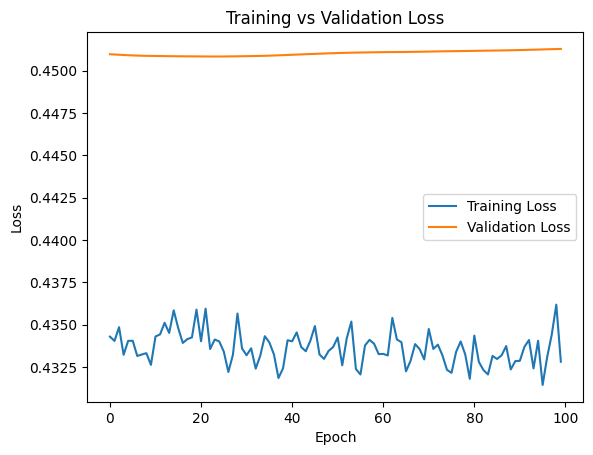

In [34]:
train_losses = []
val_losses = []

for epoch in range(epochs):
    # ---- Training ----
    model.train()
    optimizer.zero_grad()
    
    outputs = model(x_train_tensor)
    loss = criteria(outputs, y_train_tensor.view(-1))
    
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())

    # ---- Validation ----
    model.eval()
    with torch.no_grad():
        val_outputs = model(x_test_tensor)
        val_loss = criteria(val_outputs, y_test_tensor.view(-1))
        val_losses.append(val_loss.item())
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [35]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_true, y_pred)
print(f"Accuracy Score: {acc:.3f}")

Accuracy Score: 0.884


In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.97      0.93      6356
           1       0.84      0.53      0.65      1644

    accuracy                           0.88      8000
   macro avg       0.87      0.75      0.79      8000
weighted avg       0.88      0.88      0.87      8000



In [38]:
model.eval()
with torch.no_grad():
    preds = model(x_test_tensor)

    # compute test loss
    test_loss = criteria(preds, y_test_tensor.view(-1))
    print(f"\n✅ Test Loss: {test_loss.item():.4f}")

    # convert logits → predicted class
    predicted_classes = torch.argmax(preds, dim=1)

    # numpy conversion
    y_true = y_test_tensor.view(-1).cpu().numpy()
    y_pred = predicted_classes.cpu().numpy()


✅ Test Loss: 0.4513


In [39]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc:.3f}")

from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

Test Accuracy: 0.857
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.72      0.44      0.55       393

    accuracy                           0.86      2000
   macro avg       0.80      0.70      0.73      2000
weighted avg       0.85      0.86      0.84      2000

